# Example notebook on loading and visualizing glacier data
- loading and visualising geotiff, shapefiles, csv's
- starting point for doing data analyses
- example for one of the ContinuIX glaciers; 
- when applying to other glaciers it's possible issues/errors occur if the data are not exactly in the same format

M. Izeboud, Brussels, March 2026

## 0. Import modules, set path


Suggested folder structure:

```
ContinuIX/
├── ContinuIX_WP1_code/
│   ├── notebooks/
│   └── scripts/
└── ContinuIX_WP1_data/
    ├── 00_Example/
    └── 06_Hofsjokull/
```

In [ ]:
import numpy as np
import xarray as xr 
import rioxarray as rioxr ## needed for loading .grid files with xarray
import geopandas as gpd 
import os
import matplotlib.pyplot as plt
import pandas as pd

## to go from notebooks (current working directory) to data: two levels up to walk to 'ContinuIX', then one level down to 'data' and another level down into each glacier directory
## NB: I work on macbook, so filepaths are 'folder/otherfolder/subfolder' 
##     If you work on windows: filepaths are 'folder\otherfolder\subfolder' (backslashes instead of forward slashes)
## NB: if you have special charachters in your paths (space, parentheses, etc) these can be difficult to work with: 
##     its easier to avoid these and name all your folders and files with '_' instead of spaces.
path2glacierdata = '../../ContinuIX_WP1_data/11_Aletsch/'


## view content of directory to check if the path is correct
os.listdir(path2glacierdata)


['aletsch_velocity_validation',
 'aletsch_smb_extrapolated_2000-2025',
 'aletsch_h_multidate.prj',
 '.DS_Store',
 'aletsch_firn_density_1910-2024',
 'aletsch_smb_filt_2017-2023.csv',
 'aletsch_dem_2017-2023',
 'aletsch_h_20170901.grid',
 'aletsch_h_multidate.qmd',
 'aletsch_dhdt_20170901-20230823.tif',
 'aletsch_h_multidate.shx',
 'aletsch_h_multidate.cpg',
 'aletsch_h_multidate.shp',
 'aletsch_mask_2017-2023',
 'aletsch_v_2011-2019',
 'aletsch_v_2011-2019.zip',
 'aletsch_smb_raw_1912-2023.dat',
 'aletsch_h_multidate.dbf']

## 1. Loading 2D data: 


### 1.1 geotiff (/ netcdf) 

In [5]:
## load Aletsch mask: .tif file 
mask_file_17 = os.path.join(path2glacierdata, 'aletsch_mask_2017-2023', 'aletsch_mask_20170901.tif') # use os.path.join to create the path to the file (robust method across mac/windows/linux operating systems)
aletsch_mask_17 = xr.open_dataset(mask_file_17)  # To open geotiffs with xarray, make sure to have package 'rioxarray' installed

## view the xr.DataSet: has 3 dimensions (band, x, y). 
# The 'band' dimension is 1, which means there is only one layer of data (the mask). 
display(aletsch_mask_17)

# To plot 2D data, we can select the band-layer and drop this dimension to only have a (x,y) matrix
aletsch_mask_17 = aletsch_mask_17.isel(band=0).drop_vars('band')  # select the first (and only) band and drop the 'band' dimension


## load the other mask as well
aletsch_mask_23 = xr.open_dataset(os.path.join(path2glacierdata, 'aletsch_mask_2017-2023', 'aletsch_mask_20230823.tif'))  # To open geotiffs with xarray, make sure to have package 'rioxarray' installed
aletsch_mask_23 = aletsch_mask_23.isel(band=0).drop_vars('band')  # select the first (and only) band and drop the 'band' dimension

/opt/anaconda3/envs/continuix/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


<xarray.Dataset> Size: 11MB
Dimensions:      (band: 1, x: 1242, y: 2128)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 10kB 2.638e+06 2.638e+06 ... 2.65e+06 2.65e+06
  * y            (y) float64 17kB 1.157e+06 1.157e+06 ... 1.136e+06 1.136e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 11MB ...

/opt/anaconda3/envs/continuix/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


#### getting some information

In [6]:
print(aletsch_mask_17.rio.crs) ## check coordinate reference system (CRS) of the data
print(aletsch_mask_23.rio.crs) ## check coordinate reference system (CRS) of the data

## view some data values
print(aletsch_mask_17['band_data'].values) ## using .values extracts the matrix of data from the xr.DataArray as numpy array.
print('mean (as numpy array):', np.nanmean(aletsch_mask_17['band_data'].values)) ## can do calculations on the array
print('mean (as dataArray)  :', aletsch_mask_17['band_data'].mean() ) ## but: you can work with xarray objects directly, no need to convert to numpy arrays to do calculations. da.mean() will ignore nans by default, so you get the mean of the valid data values.

EPSG:2056
EPSG:2056
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
mean (as numpy array): 3050.783
mean (as dataArray)  : <xarray.DataArray 'band_data' ()> Size: 4B
array(3050.783, dtype=float32)
Coordinates:
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Area


#### plot xarray data examples
- xarray variables are stored as 'dataArray'. An 'dataSet' can have multiple variables
- If you have a dataSet, you first need to extract the individual dataArray 

Text(0.5, 0.98, 'Aletsch glacier masks')

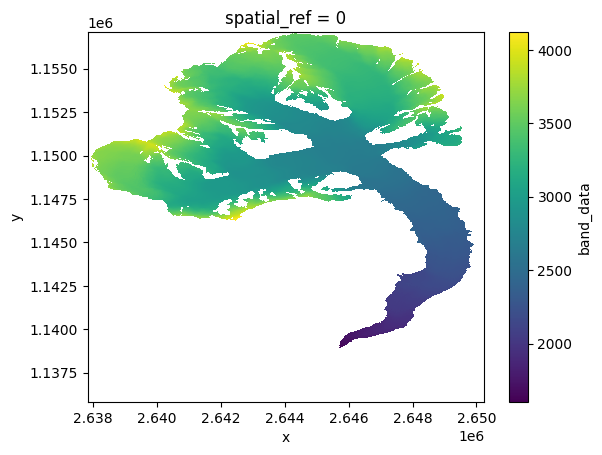

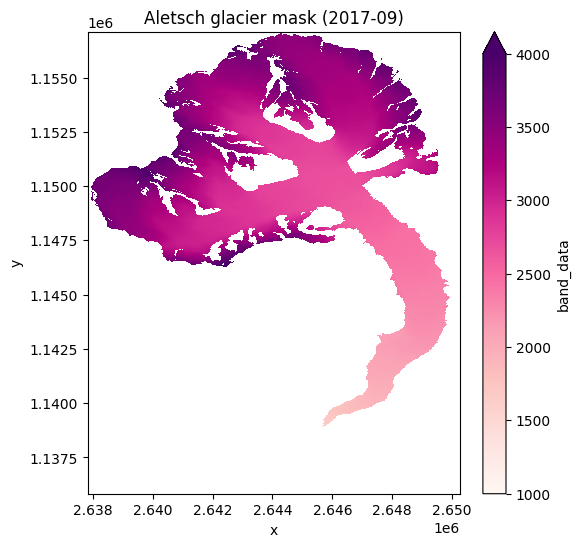

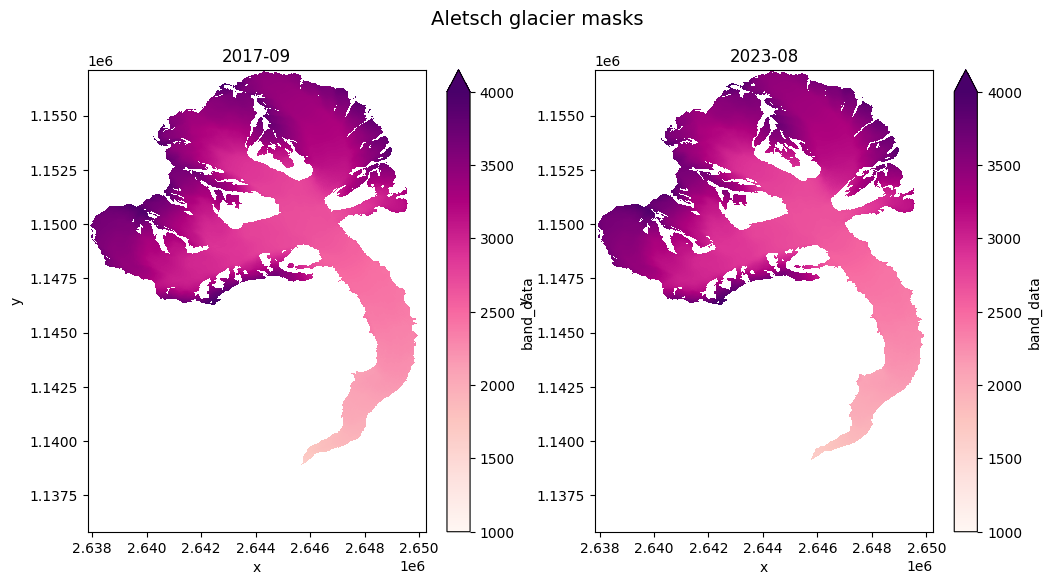

In [7]:
## plot xarray data: basic command
aletsch_mask_17['band_data'].plot.imshow()

## working with matplotlib to have more control over the plot (e.g. add title, axis labels, change figure size, etc.); great for making subplots
fig, ax = plt.subplots(figsize=(6,6))
aletsch_mask_17['band_data'].plot.imshow(ax=ax, # specify the axis to plot on
                                      vmin=1000, vmax=4000, cmap='RdPu' ## colorbar settings
                                      )
ax.set_title('Aletsch glacier mask (2017-09)', fontsize=12)

## subplots 
fig, ax = plt.subplots(1,2, figsize=(12,6)) # create a figure with 1 row and 2 columns of subplots
aletsch_mask_17['band_data'].plot.imshow(ax=ax[0], vmin=1000, vmax=4000, cmap='RdPu') # plot the first mask on the first subplot
ax[0].set_title('2017-09', fontsize=12)
aletsch_mask_23['band_data'].plot.imshow(ax=ax[1], vmin=1000, vmax=4000, cmap='RdPu') # plot the second mask on the second subplot
ax[1].set_title('2023-08', fontsize=12) 
fig.suptitle('Aletsch glacier masks', fontsize=14) # add a title for the entire figure

## 1.3 Open .grid files

In [8]:
grid_file1 = os.path.join(path2glacierdata, 'aletsch_smb_extrapolated_2000-2025', '2000_ann_obs.grid')
grid_file2 = os.path.join(path2glacierdata, 'aletsch_smb_extrapolated_2000-2025', '2024_ann_obs.grid')

ds_smb1 = xr.open_dataset(grid_file1,engine='rasterio') # specify which back-end to use to open the file when loading .grid
ds_smb1 = ds_smb1.isel(band=0).drop_vars('band').rename({'band_data':'smb'})  # select the first (and only) band and drop the 'band' dimension, rename the data variable to 'smb' for convenience
ds_smb1 

print(ds_smb1.rio.crs ) ## no CRS information in these files



None


#### Opening (and plotting) multiple files at once:

In [9]:
# make list of files:
import glob
aletsch_mb_filelist = os.path.join(path2glacierdata, 'aletsch_smb_extrapolated_2000-2025', '*.grid') # use wildcard to select all .grid files in the directory
mb_filelist = glob.glob(aletsch_mb_filelist) # use glob to get a list of all file paths that match the pattern
mb_filelist.sort() # sort the file list to ensure the files are in the correct order (e.g. from 2000 to 2025)
years_aletsch = np.arange(2000,2025+1)       # construct list of available years
print(f'Found {len(mb_filelist)} available files')

## if files can be assume to have exact same coordinate systems and variables, we can load them all into one xarray dataset using xr.open_mfdataset (multi-file dataset)
ds_mb_aletsch = xr.open_mfdataset(mb_filelist, 
                               engine='rasterio',
                               combine='nested',  # use combine='nested' to combine the files that have the same x,y but should be stack along a new dimension (e.g. time)
                               concat_dim='time', # specify what to call the new dimension along which the files will be concatenated 
                               compat='broadcast_equals', # how to handle differences
                               ).isel(band=0).drop_vars('band') # again drop the band dimension
ds_mb_aletsch = ds_mb_aletsch.rename({'band_data':'mb'}) # rename the data variable to 'mb' for convenience
ds_mb_aletsch.time.values ## initially the time values are just from 0 to 24 
ds_mb_aletsch = ds_mb_aletsch.assign_coords(time=years_aletsch) # replace the time values with the actual years (make sure the order of the years matches the order of the files)
ds_mb_aletsch # (time, y, x) dimensions


Found 26 available files


<xarray.Dataset> Size: 12MB
Dimensions:      (time: 26, y: 429, x: 261)
Coordinates:
  * time         (time) int64 208B 2000 2001 2002 2003 ... 2022 2023 2024 2025
  * y            (y) float64 3kB 1.573e+05 1.572e+05 ... 1.36e+05 1.359e+05
  * x            (x) float64 2kB 6.375e+05 6.376e+05 ... 6.504e+05 6.505e+05
    spatial_ref  int64 8B 0
Data variables:
    mb           (time, y, x) float32 12MB dask.array<chunksize=(1, 1, 261), meta=np.ndarray>

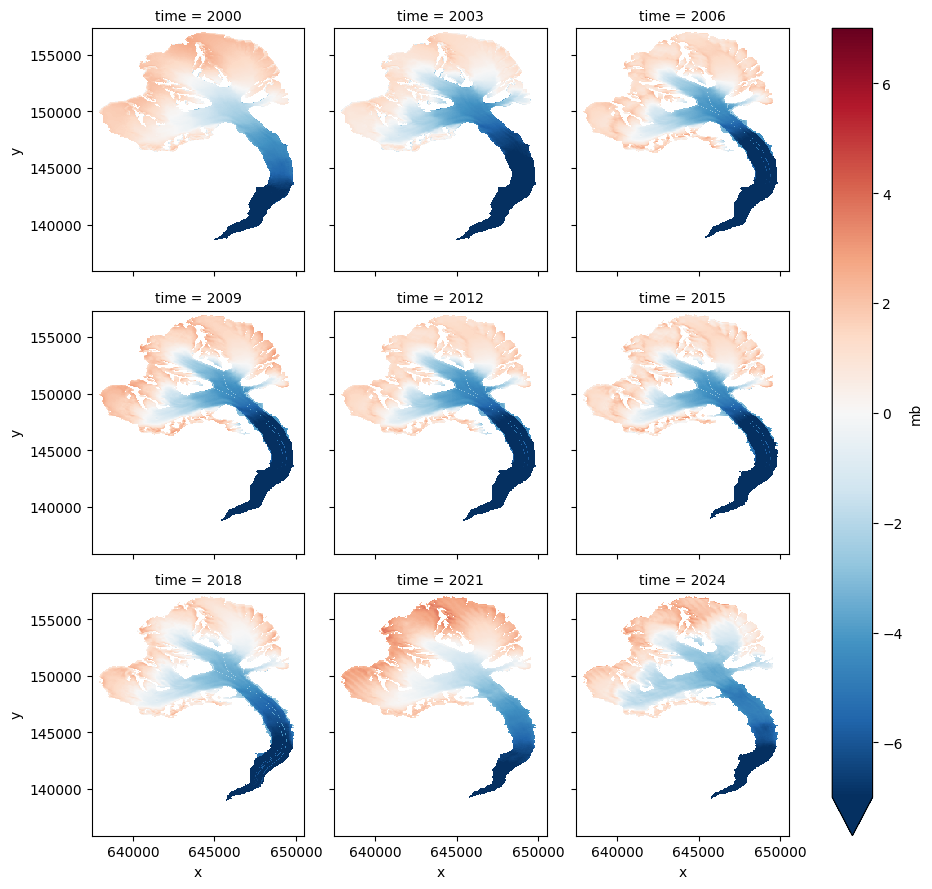

In [10]:
## plot the years of MB grid data

# ds_smb_aletsch['mb'].plot.imshow(x='x', y='y', 
#                                  col='time', col_wrap=5, ## specify the 'time' dimension to create a subplot for each time step (year) using the 'col' argument. Use 'col_wrap' to specify how many columns of subplots to have.
#                                  vmin=-5, vmax=5, cmap='RdBu_r', ## colormap arguments
#                                  ) 

## plot only a few years 
ds_mb_subset = ds_mb_aletsch['mb'].isel(time=slice(0,-1,3)) # take a slice of the data from (start, stop, step) with stop=-1 to specify last index, step=3 to take every third year
ds_mb_subset.plot.imshow(col='time', col_wrap=3,  ## specify the 'time' dimension to create a subplot for each time step (year) using the 'col' argument. Use 'col_wrap' to specify how many columns of subplots to have.
                  vmin=-7, vmax=7, cmap='RdBu_r', ## colormap arguments
                  )



#### Example: calculate differences between years

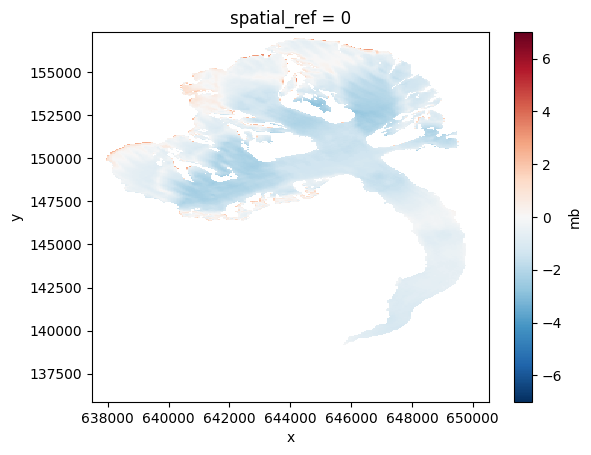

In [11]:
ds_mb_difference_2000_2024 = ds_mb_aletsch['mb'].sel(time=2024) - ds_mb_aletsch['mb'].sel(time=2000) # take the difference between the last and first time step (2024 - 2000)

ds_mb_difference_2000_2024.plot.imshow(vmin=-7, vmax=7, cmap='RdBu_r')


#### Example: aggregate data to a timeseries; plot

Text(0.5, 1.0, 'Aletsch annual mass balance (2000-2025)')

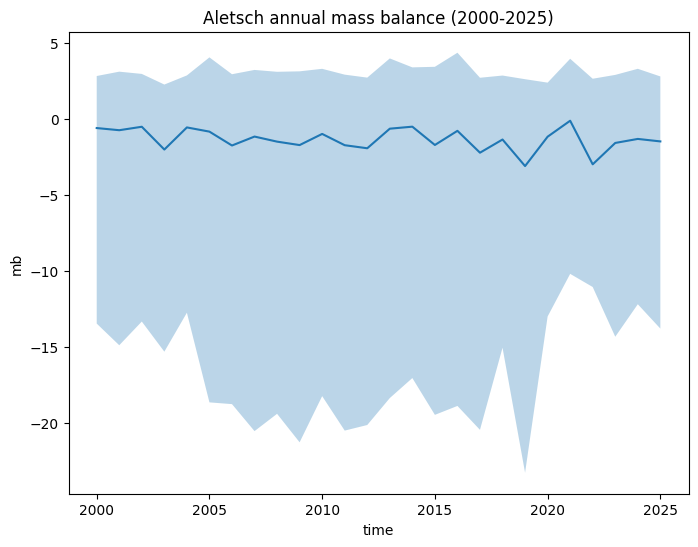

In [12]:
## plot multiple years of MB data as a timeseries
fig,ax = plt.subplots(figsize=(8,6))
## shaded area for min-max range per year
smb_min_values = ds_mb_aletsch['mb'].min(dim=['x','y']) # calculate the minimum MB value across the spatial dimensions for each time step (year)
smb_max_values = ds_mb_aletsch['mb'].max(dim=['x','y']) # calculate the maximum MB value across the spatial dimensions for each time step (year)
ax.fill_between(ds_mb_aletsch.time.values, smb_min_values.values, smb_max_values.values, alpha=0.3, label='min-max range')
## add mean MB
ds_mb_aletsch['mb'].mean(dim=['x','y']).plot(ax=ax) 
ax.set_title('Aletsch annual mass balance (2000-2025)', fontsize=12)

## 3. open tabular data
In case of tabular data: work with pandas or geopandas

### 3.1 open csv files

In [13]:
## aletsch_smb_filt
file_smb_filt = os.path.join(path2glacierdata, 'aletsch_smb_filt_2017-2023.csv')

## use pandas to read the csv file
df_smb_filt = pd.read_csv(file_smb_filt)
df_smb_filt # dataframe with columns and rows


,Name,lon,lat,elev,smb,N_yrs
0,P3,2.641830e+06,1.154798e+06,3334.985714,0.92900,7
1,PN,2.647431e+06,1.140780e+06,1989.333333,-10.70700,3
2,al10,2.649245e+06,1.143879e+06,2242.250000,-7.01550,4
3,al2,2.642935e+06,1.153856e+06,3102.000000,-0.18000,1
4,al4,2.643842e+06,1.152558e+06,2850.250000,-2.40975,4
5,al5,2.645173e+06,1.151394e+06,2724.333333,-3.60000,3
6,al6,2.646304e+06,1.149764e+06,2638.500000,-3.91725,4
7,al7,2.647506e+06,1.148367e+06,2518.500000,-5.39100,2
8,al8,2.648481e+06,1.147104e+06,2418.200000,-5.17680,5
9,al9,2.649253e+06,1.144745e+06,2297.000000,-5.85000,1


### 3.2 open .dat files
- .dat files are simple text files of which you need to extract the information in a python-usable format
- you can open these files on the computer with a text editor (e.g. notepad++, atom, textEdit) to view the structure
- presumably the files will have some header text and then some columns with the interesting info -- you need to figure out at which lines/columsn contain data. In the case of the aletsch_annual.dat, there is also a readme_data.txt with useful info.


In [14]:
## firn density .dat file
firn_density_file = os.path.join(path2glacierdata, 'aletsch_firn_density_1910-2024', 'aletsch_annual.dat')

## use pandas to read the .dat file (tabular data, but more tricky to import than .csv)

# very simple data import to see if that works:
df_firn = pd.read_csv(firn_density_file)  ## loading the full file gives us a table with 1 column and each cell contains the entire line of text (instead of parsing into multiple columns)

print('simple import without specifying parameters gives unusable table:')
display(df_firn)


simple import without specifying parameters gives unusable table:


,# Mass Balance; Grosser Aletsch; 5; annual
0,# name; date0; time0; date1; time1; period; da...
1,# (-); (yyyymmdd); (hhmm) ; (yyyymmdd); (hhmm...
2,# GLAMOS / VAW-ETHZ ; production-date 2025...
3,NMF 19120909 1200 19130920 1200 3...
4,NMG1 19120924 1200 19130920 1200 3...
...,...
1459,al-724 20240919 1200 20250915 1200 3...
1460,al-824 20240919 1200 20250915 1200 3...
1461,al-1024 20240919 1200 20250915 1200 3...
1462,24P3 20241007 1042 20251002 1024 3...


In [15]:
## add specifications to the import to correctly parse the columns and skip the metadata at the top of the file
# these settings will vary between different .dat files from different glaciers/groups.
df_firn = pd.read_csv(firn_density_file, 
                      skiprows=4,       # skip the first 4 rows of metadata at the top of the file
                      sep=r"\s+",       # the data values are separated by whitespace (one or more spaces), so we use '\s+' as the seperator to correctly parse the columns. If we don't specify this, pandas will not know how to split the columns and will read the entire line as one column, which is what we see when we load the full file without parameters.
                      engine='python',  # use the python engine for parsing, which allows us to use regex delimiters like '\s+'.
                      encoding='utf-8', # specify the encoding of the file (optional, but can help avoid issues with special characters)
                      header=None,      # the first row will be read for column headers. BUt in this file, the column names are in row idx 1 instead of row idx 3. So specify 'none' here.
                      )

print('loaded data table:')
display(df_firn) ## view dataframe: currently has no column names; need to add

## read header row from the file

df_header_row = pd.read_csv(firn_density_file, 
                            sep='; ',            # the header row is separated by '; ' instead of whitespace, so we specify this as the separator to correctly parse the column names
                            skiprows=1, nrows=1, # skip first row , read 1 line after the header. In practice this means 2 lines from the file are read, except if you specify header=None or nrows=0
                            header=0, # specify which row to use as header (0 = first row of data that is loaded).
                            engine='python', encoding='utf-8')
print('header row with colum names and units:')
display(df_header_row)

## extract columm names
colnames = df_header_row.columns.tolist() 
colnames[0] = colnames[0].replace('# ','')  # clean first column name
## clean trailing whitespaces from colnames
colnames = [name.strip() for name in colnames]
## update colnames in the datatable
df_firn.columns = colnames

print('Final data table that can be used for analysis:')
display(df_firn)


loaded data table:


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NMF,19120909,1200,19130920,1200,376.0,0,647166.0,150081.0,2850.0,...,700,4,-1120,2,6,1094,1085,134,0,glrep
1,NMG1,19120924,1200,19130920,1200,361.0,0,647089.0,150780.0,2802.0,...,539,6,592,4,6,873,870,71,0,glrep
2,NMK,19120914,1200,19130920,1200,371.0,3,646935.0,149232.0,2658.3,...,539,6,53,2,6,833,832,6,0,glrep
3,NMS,19120926,1200,19130920,1200,359.0,0,647243.0,150364.0,2759.8,...,539,6,53,2,6,849,849,6,0,glrep
4,NMT1,19120925,1200,19130920,1200,360.0,0,645782.0,150780.0,2741.1,...,539,6,646,4,6,873,870,77,0,glrep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,al-724,20240919,1200,20250915,1200,361.0,1,647498.0,148358.0,2516.0,...,900,1,-5607,1,1,95,45,84,0,mh
1457,al-824,20240919,1200,20250915,1200,361.0,1,648514.0,147072.0,2407.0,...,900,1,-5391,1,1,92,45,80,0,mh
1458,al-1024,20240919,1200,20250915,1200,361.0,1,649283.0,144095.0,2249.0,...,900,1,-7137,1,1,116,45,107,0,mh
1459,24P3,20241007,1042,20251002,1024,360.0,1,641830.9,154796.9,3333.3,...,498,2,1350,1,3,16,10,13,1,ab


header row with colum names and units:


,# name,date0,time0,date1,time1,period,date_quality,x_pos,y_pos,z_pos,...,density,density_quality,mb_we,measurement_quality,measurement_type,mb_error,reading_error,density_error,error_evaluation_method,source
0,# (-),(yyyymmdd),(hhmm),(yyyymmdd),(hhmm),(d),(#),(m),(m),(m a.s.l.),...,(kg m-3),(#),(mm w.e.),(#),(#),(mm w.e.),(mm w.e.),(mm w.e.),(#),(-)


Final data table that can be used for analysis:


,name,date0,time0,date1,time1,period,date_quality,x_pos,y_pos,z_pos,...,density,density_quality,mb_we,measurement_quality,measurement_type,mb_error,reading_error,density_error,error_evaluation_method,source
0,NMF,19120909,1200,19130920,1200,376.0,0,647166.0,150081.0,2850.0,...,700,4,-1120,2,6,1094,1085,134,0,glrep
1,NMG1,19120924,1200,19130920,1200,361.0,0,647089.0,150780.0,2802.0,...,539,6,592,4,6,873,870,71,0,glrep
2,NMK,19120914,1200,19130920,1200,371.0,3,646935.0,149232.0,2658.3,...,539,6,53,2,6,833,832,6,0,glrep
3,NMS,19120926,1200,19130920,1200,359.0,0,647243.0,150364.0,2759.8,...,539,6,53,2,6,849,849,6,0,glrep
4,NMT1,19120925,1200,19130920,1200,360.0,0,645782.0,150780.0,2741.1,...,539,6,646,4,6,873,870,77,0,glrep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,al-724,20240919,1200,20250915,1200,361.0,1,647498.0,148358.0,2516.0,...,900,1,-5607,1,1,95,45,84,0,mh
1457,al-824,20240919,1200,20250915,1200,361.0,1,648514.0,147072.0,2407.0,...,900,1,-5391,1,1,92,45,80,0,mh
1458,al-1024,20240919,1200,20250915,1200,361.0,1,649283.0,144095.0,2249.0,...,900,1,-7137,1,1,116,45,107,0,mh
1459,24P3,20241007,1042,20251002,1024,360.0,1,641830.9,154796.9,3333.3,...,498,2,1350,1,3,16,10,13,1,ab


### Plotting timeseries / dataframe

<Axes: xlabel='date0_dt'>

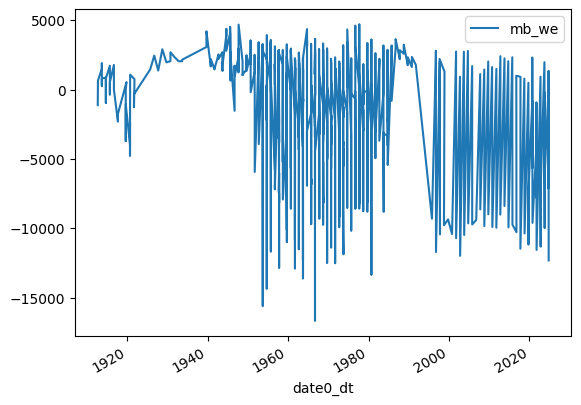

In [16]:
## preprocessing

## add date0 and date1 (string format) as datetime format (useful for plottign in timeseries)
df_firn['date0_dt'] = pd.to_datetime(df_firn['date0'].astype(str), format='%Y%m%d')
df_firn['date1_dt'] = pd.to_datetime(df_firn['date1'].astype(str), format='%Y%m%d')


## plot 

df_firn.plot(x='date0_dt', y='mb_we', # mb_we is point mas balance [mm w.e. / kg m-2]	(see readme_data.txt in the aletsch_firn_density folder)
             kind='line',
            #  kind='scatter',
             )

### 3.3 open .shp files
Use geopandas: it's still tabular data but now you can plot it on your gridded spatial data

EPSG:2056


,prf_name,prf_id,pt_id,sgi_id,z_surf,z_bed,thk,thk_min,thk_max,reference,doi,investigat,sponsor,comment,geometry
0,20110322_Aletsch_BGR_flight3_profil-014,20110322_20110322_014,41,B36/26,2808.03,2776.711,31.319,25.763041,36.874959,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2643426.809 1149855.385)
1,20110322_Aletsch_BGR_flight3_profil-014,20110322_20110322_014,42,B36/26,2808.10,2776.033,32.067,26.497763,37.636237,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2643427.269 1149854.495)
2,20110322_Aletsch_BGR_flight3_profil-014,20110322_20110322_014,43,B36/26,2808.10,2775.358,32.742,27.160781,38.323219,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2643427.739 1149853.615)
3,20110322_Aletsch_BGR_flight3_profil-014,20110322_20110322_014,44,B36/26,2808.17,2774.681,33.489,27.894521,39.083479,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2643428.199 1149852.725)
4,20110322_Aletsch_BGR_flight3_profil-014,20110322_20110322_014,45,B36/26,2808.24,2774.006,34.234,28.626296,39.841704,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2643428.669 1149851.845)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101384,20090331_Aletsch_BGR_flight1_profil-010,20090331_20090331_010,892,B36/26,3491.79,3417.539,74.251,67.932935,80.569065,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2641063.287 1150829.377)
101385,20090331_Aletsch_BGR_flight1_profil-010,20090331_20090331_010,893,B36/26,3491.61,3417.349,74.261,67.942757,80.579243,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2641063.967 1150830.107)
101386,20090331_Aletsch_BGR_flight1_profil-010,20090331_20090331_010,894,B36/26,3491.42,3417.160,74.260,67.941775,80.578225,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2641064.647 1150830.837)
101387,20090331_Aletsch_BGR_flight1_profil-010,20090331_20090331_010,895,B36/26,3491.26,3416.968,74.292,67.973207,80.610793,VAW (2012),10.18750/icethickness.2020.r2020,"Bauder, A.","Electra-Massa AG; Kanton Wallis, Dienststelle ...",None,POINT (2641065.327 1150831.577)


<Axes: >

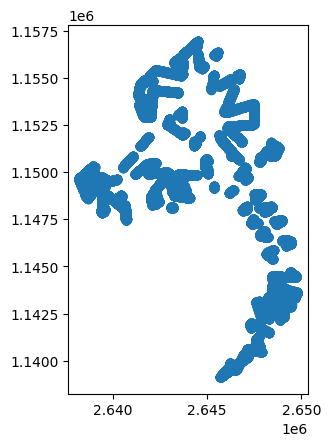

In [17]:
aletsch_h_file = os.path.join(path2glacierdata, 'aletsch_h_multidate.shp')
aletsch_h = gpd.read_file(aletsch_h_file)
print(aletsch_h.crs) ## check coordinate reference system of the shapefile

## show data table
display(aletsch_h)  ## looks like a table (dataframe)

## simple data plot , uses the [geometry] column of the dataframe
aletsch_h.plot() 


## converting a pandas dataframe to a geopandas dataframe

EPSG:2056


<Axes: >

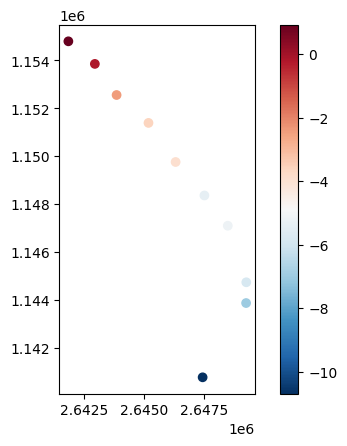

In [19]:
## the df_smb_filt dataframe contains values of SMB at stake locations, and includes latitude/longitude. This can be converted to geopandas dataframe 
print(aletsch_h.crs)
gdf_smb_stakes = gpd.GeoDataFrame(df_smb_filt, 
                                  geometry=gpd.points_from_xy(df_smb_filt.lon, df_smb_filt.lat),  ## make geometry from the relevant columns
                                  crs='EPSG:2056' ## specify CRS. I'm assuming it's the same one as the thickness data, but if the assumption is wrong the data will end up in the wrong place.
                                  ) 

## you can now plot the stakes spatially
gdf_smb_stakes.plot(column='smb', cmap='RdBu_r', legend=True) ## plot the stakes, colored by the 'smb' column, with a colormap and legend


# Combining data in a plot

In [20]:
'''
## 1. select a single mass balance year, or the mean, or what you like. Point is to convert the ds_mb_aletsch (time, x, y) to a 2D array (x,y)
## Using ds.sel() gives you the option to select a VALUE of the 'time' parameter. Using .isel() will select by index.
'''

# ds_mb_plot = ds_mb_aletsch['mb'].sel(time=2018) 
# ds_mb_plot = ds_mb_aletsch['mb'].isel(time=-1) # select the last time steps
ds_mb_plot = ds_mb_aletsch['mb'].mean(dim='time') # take the mean across the time dimension to get an average mass balance over the years for each (x,y) point



CRS ds_mb_aletsch: None


/opt/anaconda3/envs/continuix/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


--> only the plot with EPSG:21781 shows the stakes in the correct location on the glacier, so we can conclude that this is the correct CRS to implement for the data


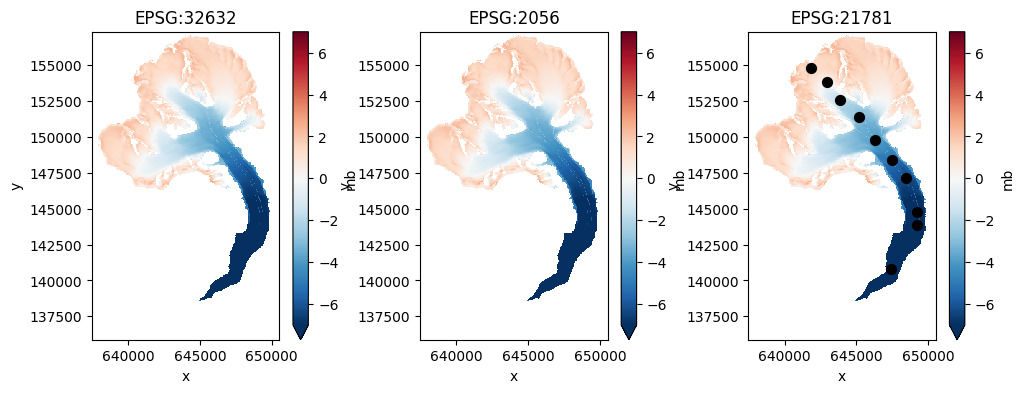

In [21]:
## 2. check CRS and if reprojection is necessary

## check/fix projection information:
print('CRS ds_mb_aletsch:', ds_mb_plot.rio.crs ) ## no CRS information in these files

## need to assume a crs for these coordinates. Options:
crs_utm     = 'EPSG:32632' ## UTM zone 32N, in meters, commonly used for the Alps
crs_swiss   = 'EPSG:2056' ## CH1903 / LV95 ## swiss CRS
crs_swiss_old = 'EPSG:21781' ## CH1903 / LV03 ## older swiss CRS, still used in some datasets'

## test all likely projections
ds_mb_plot_32632 = ds_mb_plot.rio.write_crs(crs_utm) ## write the assumed CRS to the dataset (this does not change the coordinates, just adds the information about what CRS they are in)
ds_mb_plot_2056 = ds_mb_plot.rio.write_crs(crs_swiss) 
ds_mb_plot_21781 = ds_mb_plot.rio.write_crs(crs_swiss_old) 

## stake data: assumed EPSG:2056. Need to reproject to the same CRS as the other data, if they are not in the same CRS (if they are already in the same CRS, this step will not change anything)
gdf_smb_stakes_32632 = gdf_smb_stakes.to_crs(ds_mb_plot_32632.rio.crs) 
gdf_smb_stakes_2056 = gdf_smb_stakes.to_crs(ds_mb_plot_2056.rio.crs)
gdf_smb_stakes_21781 = gdf_smb_stakes.to_crs(ds_mb_plot_21781.rio.crs)

## 3. plot
fig,axs=plt.subplots(1,3, figsize=(12,4))
ax=axs[0]
ds_mb_plot_32632.plot(ax=ax, vmin=-7, vmax=7, cmap='RdBu_r') 
gdf_smb_stakes_32632.plot(ax=ax, color='black', legend=False, markersize=50, edgecolor='k') ## plot the stakes on top of the grid data, with larger markers and black edgecolor for better visibility
ax.set_title('EPSG:32632')

ax=axs[1]
ds_mb_plot_2056.plot(ax=ax, vmin=-7, vmax=7, cmap='RdBu_r') 
gdf_smb_stakes_2056.plot(ax=ax, color='black', markersize=50, edgecolor='k') ## plot the stakes on top of the grid data, with larger markers and black edgecolor for better visibility
ax.set_title('EPSG:2056')

ax=axs[2]
ds_mb_plot_21781.plot(ax=ax, vmin=-7, vmax=7, cmap='RdBu_r') 
gdf_smb_stakes_21781.plot(ax=ax, color='black', markersize=50, edgecolor='k') ## plot the stakes on top of the grid data, with larger markers and black edgecolor for better visibility
ax.set_title('EPSG:21781')

print('--> only the plot with EPSG:21781 shows the stakes in the correct location on the glacier, so we can conclude that this is the correct CRS to implement for the data')


Text(0.5, 1.0, 'extrapolated SMB and stake SMB')

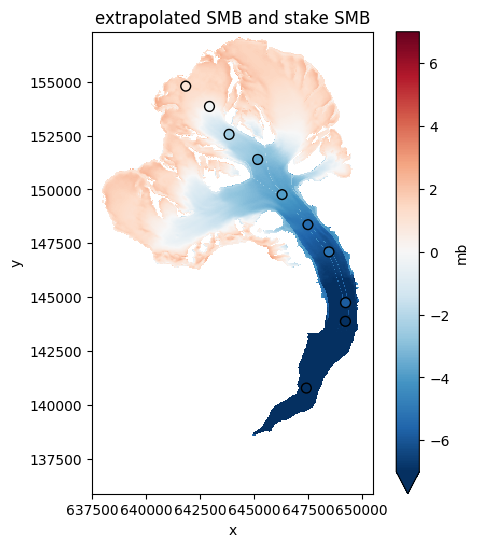

In [22]:
fig,ax=plt.subplots(figsize=(6,6))
ds_mb_plot_21781.plot(ax=ax, vmin=-7, vmax=7, cmap='RdBu_r') 
gdf_smb_stakes_21781.plot(ax=ax, column='smb', cmap='RdBu_r', 
                          vmin=-7, vmax=7,
                          legend=False, markersize=50, edgecolor='k') 
ax.set_title('extrapolated SMB and stake SMB')

Text(0.5, 1.0, 'extrapolated SMB + thickness measurements')

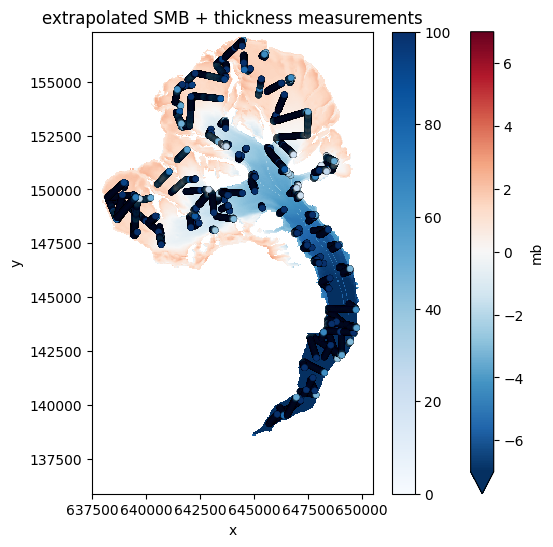

In [33]:
fig,ax=plt.subplots(figsize=(6,6))
ds_mb_plot_21781.plot(ax=ax, vmin=-7, vmax=7, cmap='RdBu_r') 
aletsch_h.to_crs(21781).plot(ax=ax, column='thk', cmap='Blues', 
                          vmin=0, vmax=100,
                          legend=True, markersize=20, edgecolor='black',linewidth=0.1) 
ax.set_title('extrapolated SMB + thickness measurements')